# Sequential Convex Programming for Trajectory Generation

### Libraries

In [18]:
%load_ext autoreload
%autoreload 2

from jax import config
config.update("jax_enable_x64", True)

import os
import copy
import pickle
import warnings
import numpy as np
from cvxpygen import cpg
import matplotlib.pyplot as plt


from mpc import RUN
from scp import prox_convex
from cvx import parse_convex_problem
from disc import jit_int_mult_fcn, jit_cal_disc_fcn
from jitting import jit_ncvx_dt_fcn_grad, jit_ncvx_ct_fcn_grad, jit_ncvx_cvx_fcn_grad, jit_ncvx_smth_fcn_grad, jit_ncvx_comp_fcn_grad

from utils import profile_with_cprofile, make_anim

from model.quad_flight.dynamics import dynamics
from model.quad_flight.params import params_fcn, scale_params, unscale_prox_results
from model.quad_flight.cost_cons import cvx_cost_fcn, cvx_cons_fcn, ncvx_dt_fcn, ncvx_ct_fcn, ncvx_cvx_fcn, ncvx_cvx_cp_fcn, ncvx_smth_fcn, ncvx_comp_fcn
from model.quad_flight.plot import qf_plot, animation

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters

In [19]:
t_f = 10.0  # Total simulation time [s]
K = 32 # Total number of nodes

free_final_time = True
time_dil = True

params = params_fcn(t_f, K, free_final_time, time_dil)

params_sc = scale_params(copy.deepcopy(params))
params_sc = dynamics(copy.deepcopy(params_sc))

### Call functions

In [20]:
fcn_dict = {}

fcn_dict['cvx_cost_fcn'] = cvx_cost_fcn
fcn_dict['cvx_cons_fcn'] = cvx_cons_fcn

In [21]:
fcn_dict['cal_disc_jitted'] = jit_cal_disc_fcn(params_sc)
fcn_dict['int_mult_jitted'] = jit_int_mult_fcn(params_sc)

In [22]:
fcn_dict['ncvx_dt_fcn_jitted'], fcn_dict['ncvx_dt_fcn_grad_jitted'] = jit_ncvx_dt_fcn_grad(ncvx_dt_fcn, params_sc)
fcn_dict['ncvx_ct_fcn_jitted'], fcn_dict['ncvx_ct_fcn_grad_jitted'] = jit_ncvx_ct_fcn_grad(ncvx_ct_fcn, params_sc)

In [23]:
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------
fcn_dict['ncvx_cvx_fcn'] = ncvx_cvx_fcn
fcn_dict['ncvx_cvx_cp_fcn'] = ncvx_cvx_cp_fcn

fcn_dict['ncvx_cvx_fcn_jitted'], fcn_dict['ncvx_cvx_fcn_grad_jitted'] = jit_ncvx_cvx_fcn_grad(ncvx_cvx_fcn, params_sc)
fcn_dict['ncvx_smth_fcn_jitted'], fcn_dict['ncvx_smth_fcn_grad_jitted'] = jit_ncvx_smth_fcn_grad(ncvx_smth_fcn, params_sc)
fcn_dict['ncvx_comp_fcn_jitted'], fcn_dict['ncvx_comp_fcn_grad_jitted'] = jit_ncvx_comp_fcn_grad(ncvx_comp_fcn, params_sc)
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------

### Code generation

In [24]:
if not(params['use_generated_code']) or params['generate_code']:
    # Parse problem if you are not using the generated code
    cvx_prb = parse_convex_problem(params_sc, fcn_dict)

In [25]:
if params['generate_code']:
    # Generate code
    code_dir = "quad_flight_solver"
    !rm -rf quad_flight_solver/*
    os.makedirs(code_dir, exist_ok=True)  # <- This ensures the directory exists
    cpg.generate_code(cvx_prb, solver = params['convex_solver'], wrapper=True, code_dir=code_dir)

zsh:1: no matches found: quad_flight_solver/*
Generating code with CVXPYgen ...
CVXPYgen finished generating code.
Compiling python wrapper with CVXPYgen ... 


/Users/su781/miniforge3/envs/trajopt/lib/python3.13/site-packages/setuptools/__init__.py:94: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)


-- The C compiler identification is AppleClang 15.0.0.15000040
-- The CXX compiler identification is AppleClang 15.0.0.15000040
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Apple Silicon detected: Configuring build for arm64
-- Building QOCO v0.1.5
-- We are on a Darwin system
-- Build Type: Release
-- Build Flags: -O3 -Wall -Wextra
-- Using 32 byte integers
-- Using double precision floating point
-- Using double precision floats
-- Long integers (64bit) are OFF
-- Static library build is ON
-- Shared library build is ON
-- Unit testing suite build is OFF
-- Configuring done (1.2s)
-- Generating done (0.1s)
-- Build files ha

ld: warning: duplicate -rpath '/Users/su781/miniforge3/envs/trajopt/lib' ignored
ld: warning: object file (/Users/su781/Desktop/gitclonescp/TrajOpt_CT-STL/quad_flight_solver/c/build/out/libcpg.a[2](cpg_workspace.c.o)) was built for newer 'macOS' version (14.0) than being linked (11.0)
ld: warning: object file (/Users/su781/Desktop/gitclonescp/TrajOpt_CT-STL/quad_flight_solver/c/build/out/libcpg.a[3](cpg_solve.c.o)) was built for newer 'macOS' version (14.0) than being linked (11.0)
ld: warning: object file (/Users/su781/Desktop/gitclonescp/TrajOpt_CT-STL/quad_flight_solver/c/build/out/libcpg.a[4](cone.c.o)) was built for newer 'macOS' version (14.0) than being linked (11.0)
ld: warning: object file (/Users/su781/Desktop/gitclonescp/TrajOpt_CT-STL/quad_flight_solver/c/build/out/libcpg.a[5](equilibration.c.o)) was built for newer 'macOS' version (14.0) than being linked (11.0)
ld: warning: object file (/Users/su781/Desktop/gitclonescp/TrajOpt_CT-STL/quad_flight_solver/c/build/out/libcpg.

CVXPYgen finished compiling python wrapper.


In [26]:
if params['use_generated_code']:
    # Use generated code
    with open('quad_flight_solver/problem.pickle', 'rb') as f:
        cvx_prb = pickle.load(f)      

    from quad_flight_solver.cpg_solver import cpg_solve
    cvx_prb.register_solve('CPG', cpg_solve)

### Prox-convex

In [27]:
prox_results_sc = prox_convex(  copy.deepcopy(params_sc), 
                                cvx_prb,
                                fcn_dict,
                                )

Ite          T-Ite        T-Disc       T-SubP       T-J_Np       S_cost       dyn_cost     ctc_cost     obs_4        obs_1        obs_2        obs_5        obs_6        obs_3        evnt_0       evnt_1       None_ct      None_comp    ptr_cost     lcd          nlcd         lc           nlc          D-NL         D-L          Rho          W-TR         Note         Staus        
0            0            0            0            0            1.0          73441.525    0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          73441.525    0.0          73442.525    0            0            0            1.0          Start        Start        
1            0.2703       0.0005       0.0903       0.1636       0.9869       22777.2963   0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          0.0          49.9038   

In [28]:
print('Total iteration      time:', round(sum(prox_results_sc['T-Ite']), 3))
print('Total discretization time:', round(sum(prox_results_sc['T-Disc']), 3))
print('Total subproblem     time:', round(sum(prox_results_sc['T-SubP']), 3))
print('Total Jax to Numpy   time:', round(sum(prox_results_sc['T-J_Np']), 3))

print('\n')

tot_dsj = sum(prox_results_sc['T-Disc']) + sum(prox_results_sc['T-SubP']) + sum(prox_results_sc['T-J_Np'])
print('Total disc-subp-j_np time:', round(tot_dsj, 3))
print('Total others         time:', round(sum(prox_results_sc['T-Ite']) - tot_dsj, 3))

print('\n')

print('Flight time:', round(prox_results_sc['S_new'].sum(), 3))

Total iteration      time: 428.178
Total discretization time: 0.394
Total subproblem     time: 229.566
Total Jax to Numpy   time: 185.665


Total disc-subp-j_np time: 415.624
Total others         time: 12.554


Flight time: 7.325


### Dump results

In [29]:
# with open('prox_results_sc.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(prox_results_sc))

In [30]:
# with open('prox_results_sc.pickle', 'rb') as f:
#     prox_results_sc = pickle.load(f)      

In [31]:
# with open('results.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(results))
    
# with open('params.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(params))

### Simulate

In [32]:
prox_results = unscale_prox_results(copy.deepcopy(prox_results_sc), params)

params = dynamics(copy.deepcopy(params))

results = RUN(copy.deepcopy(prox_results), 
                 copy.deepcopy(params))

### Plot results

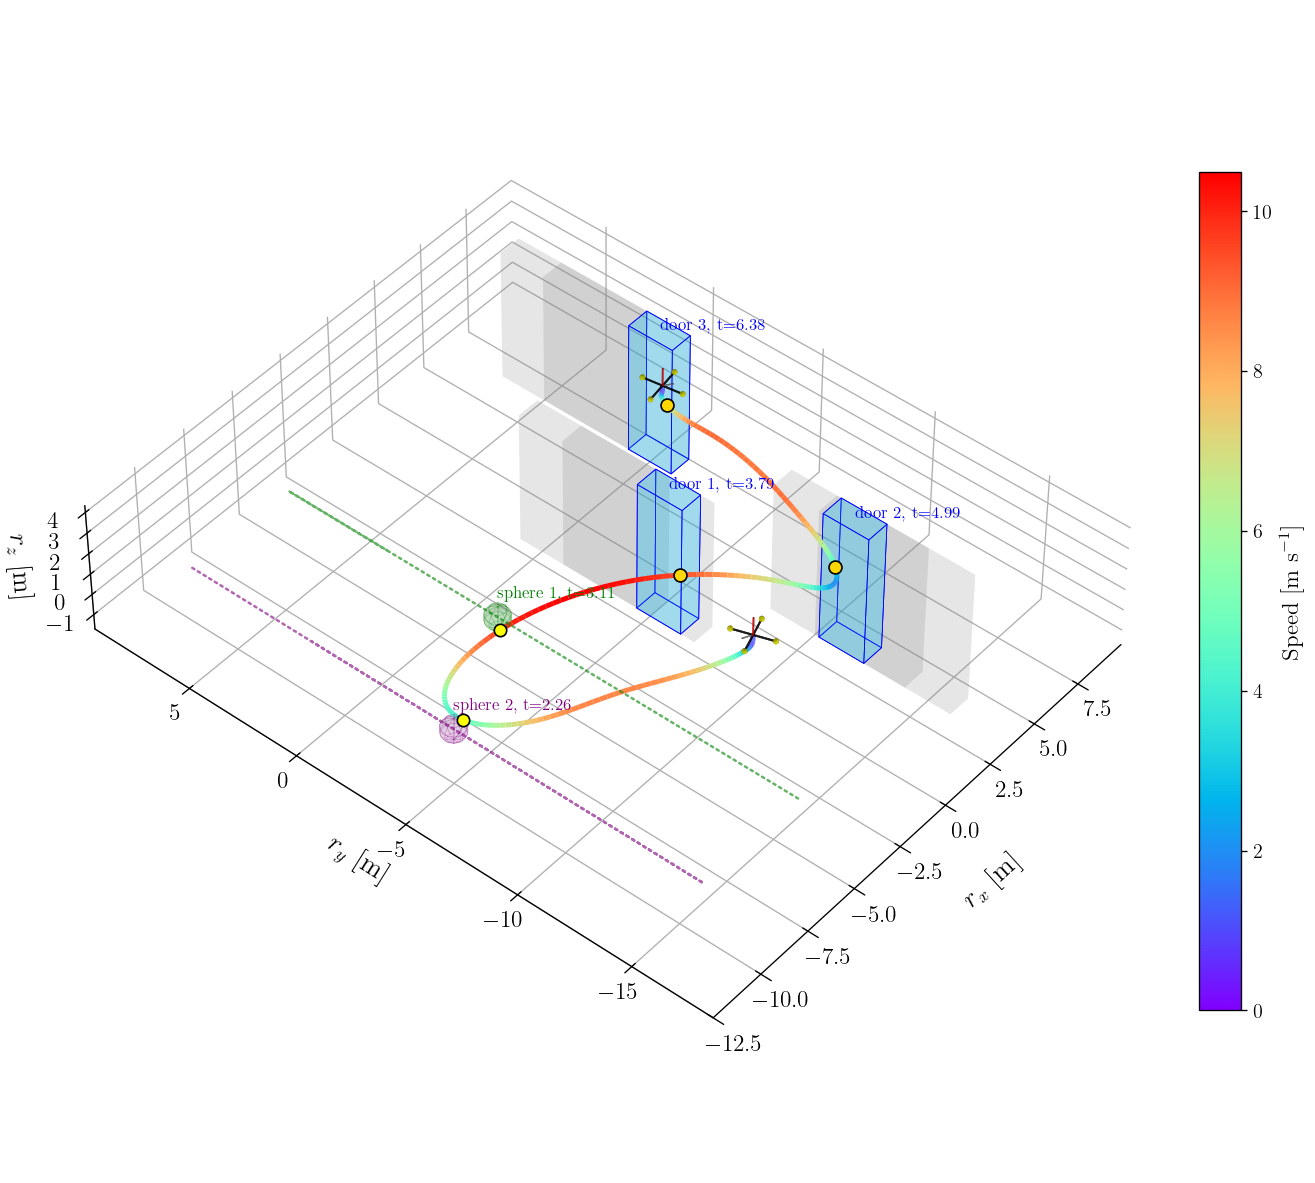

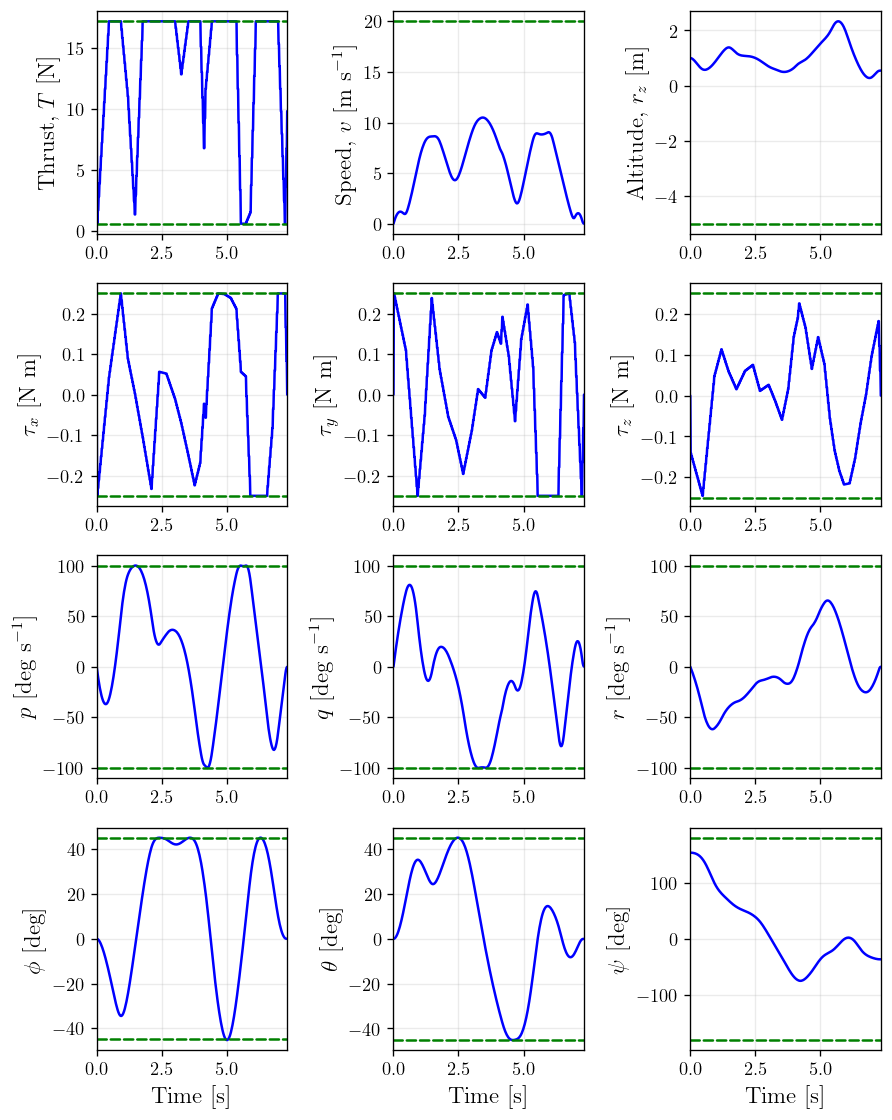

Saved static 3D figure to: Figures/qf_traj.png
Saved states/controls figure to: Figures/qf_states


In [35]:
qf_plot(results, params, 'Figures')

### Animation

In [ ]:
save_anim = False
if save_anim:
    animation(results, params, 'Figures/quad_flight', delt=2)
    make_anim(load_from = 'Figures/quad_flight/', 
              save_to = 'Figures/qf_animation',
              duration = 5.0, 
              fps = 24, 
              anim_format = 'gif')

100%|██████████| 122/122 [05:08<00:00,  2.53s/it]


Saved animation frames to: Figures/quad_flight
